In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = sns.load_dataset('tips')

In [4]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [5]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [7]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

<Axes: xlabel='total_bill', ylabel='tip'>

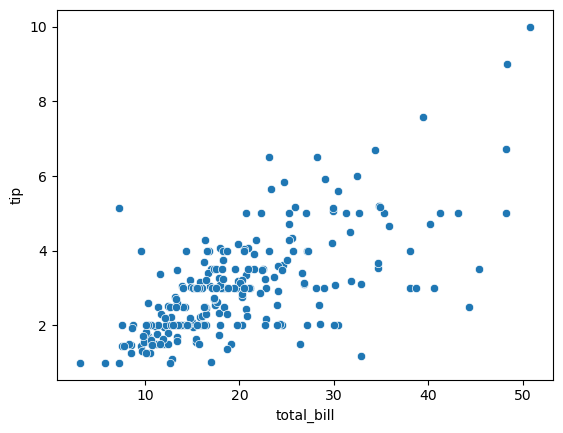

In [8]:
sns.scatterplot(x = 'total_bill' , y = 'tip' , data=df)

In [9]:
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        df[col] = LabelEncoder().fit_transform(df[col])
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


In [10]:
scalar = StandardScaler()
scalar = scalar.fit_transform(df)
scalar = pd.DataFrame(scalar, columns=df.columns)
scalar.head()

,total_bill,tip,sex,smoker,day,time,size
0,-0.314711,-1.439947,-1.343353,-0.784789,0.279158,-0.621582,-0.600193
1,-1.063235,-0.969205,0.744406,-0.784789,0.279158,-0.621582,0.453383
2,0.137780,0.363356,0.744406,-0.784789,0.279158,-0.621582,0.453383
3,0.438315,0.225754,0.744406,-0.784789,0.279158,-0.621582,-0.600193
4,0.540745,0.443020,-1.343353,-0.784789,0.279158,-0.621582,1.506958


<Axes: xlabel='total_bill', ylabel='tip'>

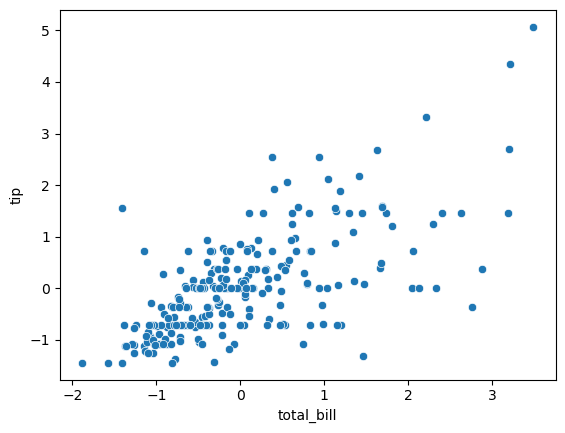

In [11]:
sns.scatterplot(x = 'total_bill' , y = 'tip' , data=scalar)

In [12]:
x = df[['total_bill']]
y = df['tip']

In [13]:
X_train, X_test , y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
X_test.head()

,total_bill
24,19.82
6,8.77
153,24.55
211,25.89
198,13.00


In [16]:
y_test.head()

24     3.18
6      2.00
153    2.00
211    5.16
198    2.00
Name: tip, dtype: float64

In [17]:
y_pred = model.predict(X_test)
y_pred 

array([3.04525623, 1.86330727, 3.55119456, 3.69452593, 2.31576375,
       2.83881627, 3.96728338, 2.26014262, 2.50615915, 2.57033737,
       2.88160176, 2.07723468, 2.06439904, 2.47407003, 2.00236009,
       2.91903905, 2.92652651, 3.23351235, 2.68478854, 5.33107064,
       3.13831465, 3.13403611, 2.4558862 , 1.94673896, 3.16077703,
       2.17564129, 2.02375283, 3.62927807, 2.68906708, 6.07767732,
       4.99734388, 1.75313465, 2.83025918, 3.09552917, 2.74040966,
       3.50092162, 2.21200895, 5.53644096, 2.33287794, 3.35010279,
       2.04942412, 2.47834858, 3.48701634, 2.03017065, 2.03124029,
       1.25361414, 2.05798121, 2.92438724, 1.73388118])

In [18]:
msc = mean_squared_error(y_pred, y_test)
r2 = r2_score(y_pred,y_test)
print("MSE: ", msc)
print("R2 Score: ", r2)

MSE:  0.5688142529229538
R2 Score:  0.4136453108083169


In [19]:
y_pred_IDV = model.predict([[25]])
y_pred_IDV

c:\Users\Malik\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.59932823])

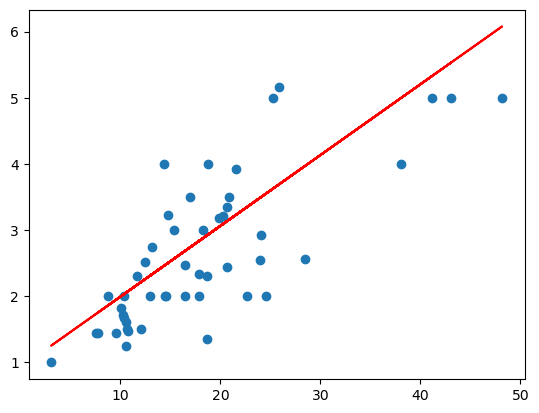

In [20]:
plt.scatter(X_test,y_test)
plt.plot(X_test, y_pred, color = 'red' )